# K-Means Clustering

## Importing the libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [16]:
dataset = pd.read_csv("Mall_Customers.csv")

In [17]:
# Same thing
# X = dataset.iloc[ : , 3:].values
X = dataset.iloc[ : , [3,4]].values # For discontinuous column

## Using the elbow method to find out the optimal number of clusters

In [18]:
from sklearn.cluster import KMeans

init="k-means++" is used to choose better starting centroids, so K-Means works faster and gives more stable, better clusters.

In [19]:
WCSS = []
for i in range(1,11):
  kmeans = KMeans(n_clusters= i , init = "k-means++", random_state = 42)
  kmeans.fit(X)
  WCSS.append(kmeans.inertia_)

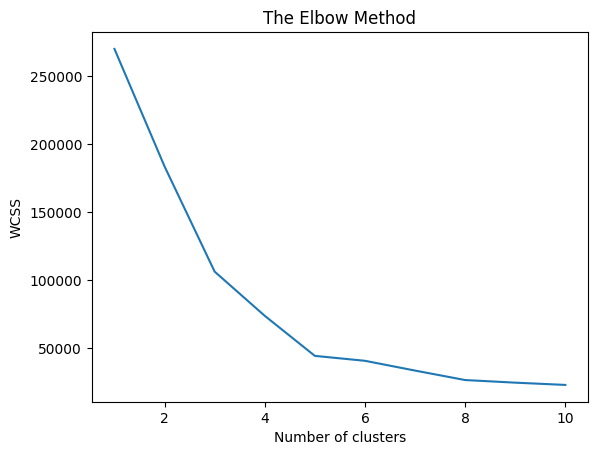

In [20]:
# plt.plot(x,y)
plt.plot(range(1, 11), WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K_Means model on the datset

In [21]:
kmeans = KMeans(n_clusters=5, init = "k-means++", random_state= 42)
y_kmeans = kmeans.fit_predict(X)

In [22]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Visualizing the clusters

### Printing the estimated salary of the customes of the 0 indexed clusters or the first cluster

In [23]:
print(X[y_kmeans == 0 , 0])

[39 40 40 40 40 42 42 43 43 43 43 44 44 46 46 46 46 47 47 48 48 48 48 48
 48 49 49 50 50 54 54 54 54 54 54 54 54 54 54 54 54 57 57 58 58 59 59 60
 60 60 60 60 60 61 61 62 62 62 62 62 62 63 63 63 63 63 63 64 64 65 65 65
 65 67 67 67 67 69 71 72 76]


### Printing the spending score of the customes of the 0 indexed clusters or the first cluster

In [24]:
print(X[y_kmeans == 0 , 1])

[61 55 47 42 42 52 60 54 60 45 41 50 46 51 46 56 55 52 59 51 59 50 48 59
 47 55 42 49 56 47 54 53 48 52 42 51 55 41 44 57 46 58 55 60 46 55 41 49
 40 42 52 47 50 42 49 41 48 59 55 56 42 50 46 43 48 52 54 42 46 48 50 43
 59 43 57 56 40 58 35 34 40]


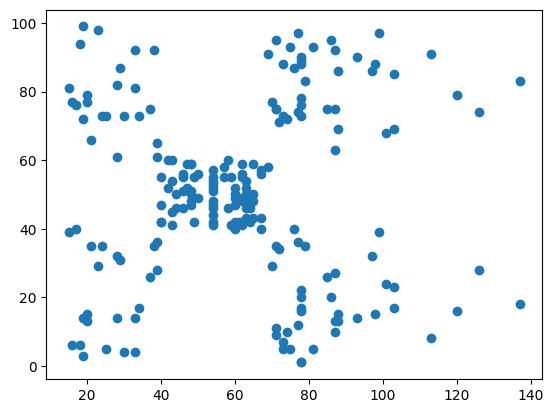

In [25]:
plt.scatter(X[:, 0],X[:, 1])
plt.show()

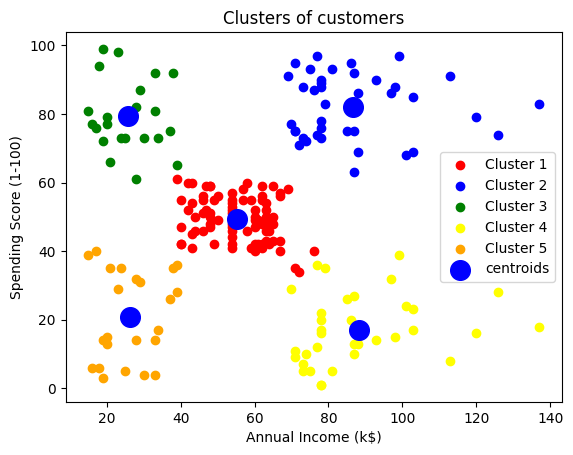

In [36]:
plt.scatter(X[y_kmeans == 0 , 0], X[y_kmeans == 0 , 1], c= "red", label = "Cluster 1")
plt.scatter(X[y_kmeans == 1 , 0], X[y_kmeans == 1 , 1], c= "blue", label = "Cluster 2")
plt.scatter(X[y_kmeans == 2 , 0], X[y_kmeans == 2 , 1], c= "green", label = "Cluster 3")
plt.scatter(X[y_kmeans == 3 , 0], X[y_kmeans == 3 , 1], c= "yellow", label = "Cluster 4")
plt.scatter(X[y_kmeans == 4 , 0], X[y_kmeans == 4 , 1], c= "orange", label = "Cluster 5")
plt.scatter(kmeans.cluster_centers_[ : , 0] , kmeans.cluster_centers_[:, 1] , s = 200, c = "blue", label = "centroids")
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

* 1st Cluster = Mid Level custermers
* 2nd Cluster = Elite customers
* 3th cluster = Impoulse customers
* 4rd Cluster = Need-Based customers
* 5th Cluster = Poor customers